# Building GPT Step by Step

In this notebook we build a **GPT-style language model from scratch** in PyTorch —
no Hugging Face, no prebuilt transformer layers. Every piece is implemented by
hand, in the order the model actually works:

> **text → tokens → embeddings → attention → transformer blocks → logits → training → generation**

### What you'll build
A working GPT-2-small-architecture model (~124M-class) that you train yourself on a
short story and then sample text from.

### Prerequisites
- Python 3.10+, PyTorch, `tiktoken` (installed in the next cell)
- Basic familiarity with PyTorch tensors and `nn.Module`

### Learning objectives
By the end you will be able to explain, from memory:
1. How BPE tokenization turns text into numbers (and why it's lossy-looking but exact)
2. Why a transformer needs *both* token and positional embeddings
3. What the Q/K/V projections, causal mask, and softmax actually compute
4. Why multi-head attention splits one projection instead of learning separate ones
5. How pre-LN residual blocks keep gradients alive through 12 layers
6. How next-token training turns raw text into a supervised signal — with zero labels

Run each cell top to bottom. Every code cell is runnable as-is.


## 0. Setup

Install the package in editable mode (quietly), then pick a device and fix the
random seed so results are reproducible.


In [1]:
%pip install -q -e ..


/workspaces/gpt-from-scratch/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch

print("torch", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch.manual_seed(123)  # reproducibility for the whole notebook


torch 2.14.0+cu130
device: cpu


## 1. Tokenization: text → numbers

A neural net can't read characters — it needs integers. We use **byte-pair
encoding (BPE)** via the GPT-2 tokenizer (`tiktoken`):

- Frequent words become **single tokens** (`" world"` → one ID)
- Rare words are split into **subword pieces** (`"unbelievable"` → `un` + `believ` + `able`)
- The mapping is **deterministic and perfectly reversible** — `decode(encode(x)) == x`

The vocabulary has **50,257** entries: 256 raw bytes + 50,000 learned merges + 1 special token.


In [3]:
from gpt_from_scratch.tokenizer import load_tokenizer, text_to_token_ids, token_ids_to_text

tokenizer = load_tokenizer()
print("vocab size:", tokenizer.n_vocab)

# A friendly sentence
text = "Hello, world!"
ids = text_to_token_ids(text)
print("text:      ", repr(text))
print("token IDs: ", ids.tolist()[0])
print("roundtrip: ", repr(token_ids_to_text(ids)))

# The tricky part: subword splits are not where you'd guess
tricky = "unbelievable"
tricky_ids = tokenizer.encode(tricky)
print("\ntext:      ", repr(tricky))
print("token IDs: ", tricky_ids)
print("pieces:    ", [tokenizer.decode([t]) for t in tricky_ids])

# And a word with a leading space tokenizes differently than without one
for w in [" world", "world"]:
    print(f"{w!r:10} -> {tokenizer.encode(w)}")


vocab size: 50257
text:       'Hello, world!'
token IDs:  [15496, 11, 995, 0]
roundtrip:  'Hello, world!'

text:       'unbelievable'
token IDs:  [403, 6667, 11203, 540]
pieces:     ['un', 'bel', 'iev', 'able']
' world'   -> [995]
'world'    -> [6894]


## 2. Embeddings: numbers → vectors

Token IDs are arbitrary labels (`15496` means nothing). An **embedding layer**
is a learned lookup table: each of the 50,257 token IDs maps to a dense vector
of dimension `emb_dim` (768 for GPT-2 small). Similar meanings end up near each
other in this space — and the table is learned by backprop, not fixed.

But embeddings alone forget **order**: "dog bites man" and "man bites dog"
would look identical as a bag of vectors. So GPT adds a second learned table —
**positional embeddings** — encoding *where* each token sits (position 0, 1, 2,
…). Input to the transformer = token embedding + positional embedding.


In [4]:
import torch.nn as nn

vocab_size, emb_dim, context_length = 50257, 768, 1024

tok_emb = nn.Embedding(vocab_size, emb_dim)   # token  -> vector
pos_emb = nn.Embedding(context_length, emb_dim)  # position -> vector

batch_size, seq_len = 2, 16
idx = torch.randint(0, vocab_size, (batch_size, seq_len))

tok_vectors = tok_emb(idx)                                   # (2, 16, 768)
pos_vectors = pos_emb(torch.arange(seq_len))                 # (16, 768)
x = tok_vectors + pos_vectors                                # broadcast over batch

print("token embeddings:     ", tuple(tok_vectors.shape))
print("positional embeddings:", tuple(pos_vectors.shape))
print("model input x:        ", tuple(x.shape))
print("\nBoth tables are nn.Parameter under the hood — learned end to end.")


token embeddings:      (2, 16, 768)
positional embeddings: (16, 768)
model input x:         (2, 16, 768)

Both tables are nn.Parameter under the hood — learned end to end.


## 3. Self-attention from scratch (the "aha" cell)

This is the heart of GPT. For each token, attention asks: *"which other tokens
should I pay attention to, and how much?"* — computed in four steps:

1. **Project** each token into a *query* (what I'm looking for), *key* (what I
   contain), and *value* (what I contribute) via three learned matrices.
2. **Score**: dot product of every query with every key → a `seq_len × seq_len`
   matrix of "how much token *i* cares about token *j*".
3. **Scale + mask**: divide by `√d` so the softmax doesn't saturate, then set
   all *future* positions to `-inf` — a token must never see what's ahead
   (this **causal mask** is what makes it a *generative* model).
4. **Softmax + mix**: turn scores into weights (rows sum to 1), then output a
   weighted sum of the *values*.

Below we do it with raw tensor ops — no `nn.Module` yet.


In [5]:
torch.manual_seed(42)

# Toy setup: 1 sequence, 6 tokens, 8-dimensional embeddings
seq_len, d = 6, 8
x = torch.randn(1, seq_len, d)

# One attention head = three learned linear projections
W_q = torch.randn(d, d)
W_k = torch.randn(d, d)
W_v = torch.randn(d, d)

Q = x @ W_q  # queries: "what am I looking for?"
K = x @ W_k  # keys:    "what do I contain?"
V = x @ W_v  # values:  "what do I contribute?"
print("Q/K/V shapes:", tuple(Q.shape), tuple(K.shape), tuple(V.shape))

# Step 2: raw attention scores, every token vs every token
scores = Q @ K.transpose(-2, -1)
print("scores shape:", tuple(scores.shape))

# Step 3: scale (keeps softmax in a healthy range) and causally mask the future
scaled = scores / (d ** 0.5)
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
scaled = scaled.masked_fill(mask, float("-inf"))

# Step 4: softmax -> weights, then mix the values
weights = torch.softmax(scaled, dim=-1)
print("weights shape:", tuple(weights.shape))
print("each row sums to 1:", weights[0].sum(dim=-1).round(decimals=4).tolist())
print("row 0 (sees only token 0):", weights[0, 0].round(decimals=3).tolist())

out = weights @ V
print("output shape:", tuple(out.shape))


Q/K/V shapes: (1, 6, 8) (1, 6, 8) (1, 6, 8)
scores shape: (1, 6, 6)
weights shape: (1, 6, 6)
each row sums to 1: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
row 0 (sees only token 0): [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
output shape: (1, 6, 8)


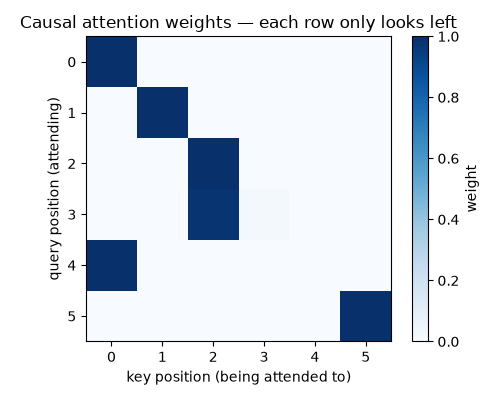

In [6]:
import matplotlib
matplotlib.use("Agg")  # headless-safe
import matplotlib.pyplot as plt
from IPython.display import Image

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights[0].detach(), cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("key position (being attended to)")
ax.set_ylabel("query position (attending)")
ax.set_title("Causal attention weights — each row only looks left")
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
fig.colorbar(im, ax=ax, label="weight")
fig.tight_layout()
fig.savefig("/tmp/attention_heatmap.png", dpi=100)
plt.close(fig)

Image("/tmp/attention_heatmap.png")


## 4. Multi-head attention (the packaged version)

One head can only learn one notion of "relevance". **Multi-head attention**
runs several heads in parallel — e.g. one head might track grammar, another
long-range topic — then merges them.

Implementation trick: instead of separate Q/K/V matrices per head, we learn
*one* big projection to `d_out` and **split it into heads** with
`view` + `transpose`. Cheaper, and exactly equivalent.

The packaged `MultiHeadAttention` does all of the previous cell, per head,
plus a final output projection.


In [7]:
from gpt_from_scratch.attention import MultiHeadAttention

torch.manual_seed(0)
mha = MultiHeadAttention(
    d_in=64, d_out=64, context_length=32, dropout=0.0, n_heads=4
)
mha.eval()

x = torch.randn(2, 16, 64)
out = mha(x)
print("in :", tuple(x.shape))
print("out:", tuple(out.shape))
assert out.shape == (2, 16, 64)
print("head dim:", mha.head_dim, "| n_heads:", mha.n_heads)


in : (2, 16, 64)
out: (2, 16, 64)
head dim: 16 | n_heads: 4


## 5. LayerNorm, GELU, FeedForward

Three supporting actors, each with a job:

- **LayerNorm** — normalizes each token's vector to mean 0 / variance 1, then
  applies a learned scale and shift. This keeps activations well-behaved as
  they flow through 12 layers. (GPT-2 uses *biased* variance — dividing by `n`,
  not `n−1` — and we match it exactly.)
- **GELU** — a smooth, S-shaped activation (like a "soft" ReLU). GPT-2 uses the
  `tanh` approximation, which is what we implement.
- **FeedForward** — a per-token two-layer MLP that expands `emb_dim → 4×emb_dim`
  (with GELU) and contracts back. This is where most of the model's parameters
  — and "knowledge" — live.


In [8]:
from gpt_from_scratch.transformer import LayerNorm, GELU, FeedForward

# LayerNorm on a toy vector: mean -> 0, variance -> 1
ln = LayerNorm(emb_dim=4)
x = torch.tensor([[1.0, 2.0, 3.0, 10.0]])
out = ln(x)
print("input:      ", x.tolist())
print("normalized:", out.round(decimals=4).tolist())
print("mean ~ 0:", round(out.mean().item(), 6),
      "| var ~ 1:", round(out.var(unbiased=False).item(), 6))

# FeedForward: 64 -> 256 -> 64, per token independently
ff = FeedForward(emb_dim=64)
x = torch.randn(2, 16, 64)
print("\nFeedForward:", tuple(x.shape), "->", tuple(ff(x).shape))
print("hidden dim inside:", ff.layers[0].out_features, "(= 4 x 64)")


input:       [[1.0, 2.0, 3.0, 10.0]]
normalized: [[-0.8485000133514404, -0.5656999945640564, -0.28279998898506165, 1.697100043296814]]
mean ~ 0: 0.0 | var ~ 1: 0.999999

FeedForward: (2, 16, 64) -> (2, 16, 64)
hidden dim inside: 256 (= 4 x 64)


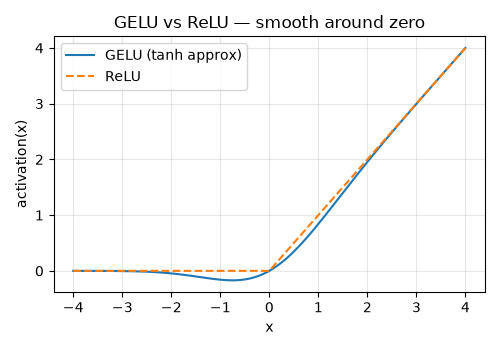

In [9]:
gelu = GELU()
xs = torch.linspace(-4, 4, 200)
ys = gelu(xs)
relu_ys = torch.clamp(xs, min=0)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(xs.numpy(), ys.numpy(), label="GELU (tanh approx)")
ax.plot(xs.numpy(), relu_ys.numpy(), "--", label="ReLU")
ax.set_xlabel("x")
ax.set_ylabel("activation(x)")
ax.set_title("GELU vs ReLU — smooth around zero")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("/tmp/gelu_curve.png", dpi=100)
plt.close(fig)

Image("/tmp/gelu_curve.png")


## 6. The transformer block

GPT stacks 12 identical blocks. Each block does two things, both wrapped in
**residual (skip) connections** so gradients flow straight through the stack:

```
input x
 │
 ├─ shortcut ───────────────────────────────────────────┐
 ▼                                                      │
LayerNorm → MultiHeadAttention → Dropout ──→ (+) ──→ y  │
                                                        │
y                                                       │
 ├─ shortcut ───────────────────────────────────────────┤
 ▼                                                      ▼
LayerNorm → FeedForward → Dropout ──────────→ (+) ──→ output
```

Note the order: **norm first, then the sublayer, then add the shortcut**
("pre-LN"). The original 2017 Transformer normalized *after* the residual add
("post-LN"), but pre-LN trains far more stably in deep stacks — which is why
GPT uses it.


In [10]:
from gpt_from_scratch.transformer import TransformerBlock

torch.manual_seed(0)
block = TransformerBlock(
    d_in=64, d_out=64, context_length=32, n_heads=4, drop_rate=0.0
)
block.eval()

x = torch.randn(2, 16, 64)
out = block(x)
print("TransformerBlock:", tuple(x.shape), "->", tuple(out.shape))
assert out.shape == x.shape  # blocks preserve shape: stackable forever


TransformerBlock: (2, 16, 64) -> (2, 16, 64)


## 7. Assembling the full GPT model

Now we stack everything into `GPTModel`:

1. token + positional embeddings → dropout
2. **N × TransformerBlock**
3. final LayerNorm
4. linear **output head**: `emb_dim → vocab_size` logits — one score per
   vocabulary token, at *every* position

We instantiate the real GPT-2 small configuration (12 layers, 12 heads,
768-dim) straight from `configs/gpt2_small.yaml`.


In [11]:
import yaml
from gpt_from_scratch.model import GPTModel, count_parameters

with open("../configs/gpt2_small.yaml", encoding="utf-8") as f:
    model_cfg = yaml.safe_load(f)["model"]
print("config:", model_cfg)

torch.manual_seed(123)
model = GPTModel(**model_cfg)
n_params = count_parameters(model)
print(f"\nTotal parameters: {n_params:,}")

model.eval()
idx = torch.randint(0, model_cfg["vocab_size"], (2, 16))
with torch.no_grad():
    logits = model(idx)
print("input token IDs:", tuple(idx.shape))
print("output logits:  ", tuple(logits.shape))
assert logits.shape == (2, 16, 50257)


config: {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}

Total parameters: 163,009,536
input token IDs: (2, 16)
output logits:   (2, 16, 50257)


## 8. Data: turning raw text into training batches

Language modeling is **self-supervised** — no labels needed. The trick:

1. Tokenize the raw text.
2. Slide a window of length `max_length` across the token stream.
3. For each window, the **target is the input shifted right by one token**.

So the model always learns: *"given these tokens, predict the very next one."*
We train on Edith Wharton's short story *The Verdict* (~20 KB) — the same text
used in Raschka's book — split 90/10 into train/validation.


In [12]:
from gpt_from_scratch.data import (
    load_text, train_val_split, GPTDatasetV1, create_dataloader,
)

text = load_text("../data/the-verdict.txt")
print("characters:", len(text))
print("first 200 chars:", repr(text[:200]))

# Sliding-window demo with tiny windows so the shift is visible
tokenizer = load_tokenizer()
ds = GPTDatasetV1(text, tokenizer, max_length=8, stride=4)
print("\nnumber of chunks:", len(ds))

inp, tgt = ds[3]
print("input IDs: ", inp.tolist())
print("target IDs:", tgt.tolist())
print("decoded input: ", repr(tokenizer.decode(inp.tolist())))
print("decoded target:", repr(tokenizer.decode(tgt.tolist())))
print("target == input shifted by one:", torch.equal(tgt[:-1], inp[1:]))

# Train/val split + batched dataloaders
train_text, val_text = train_val_split(text, train_ratio=0.9)
train_loader = create_dataloader(
    train_text, batch_size=2, max_length=256, stride=256,
    shuffle=True, drop_last=True,
)
val_loader = create_dataloader(
    val_text, batch_size=2, max_length=256, stride=256,
    shuffle=False, drop_last=False,
)
xb, yb = next(iter(train_loader))
print("\ntrain batches:", len(train_loader), "| val batches:", len(val_loader))
print("batch shapes (inputs, targets):", tuple(xb.shape), tuple(yb.shape))


characters: 20479
first 200 chars: 'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a'

number of chunks: 1285
input IDs:  [15632, 438, 2016, 257, 922, 5891, 1576, 438]
target IDs: [438, 2016, 257, 922, 5891, 1576, 438, 568]
decoded input:  ' genius--though a good fellow enough--'
decoded target: '--though a good fellow enough--so'
target == input shifted by one: True

train batches: 9 | val batches: 1
batch shapes (inputs, targets): (2, 256) (2, 256)


In [13]:
# Tiny Shakespeare: a second corpus for continued training
shakespeare_url = (
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/"
    "data/tinyshakespeare/input.txt"
)
shakespeare_text = load_text(
    "../data/tiny-shakespeare.txt",
    url=shakespeare_url,
)
print("\nShakespeare characters:", len(shakespeare_text))
print("first 200 chars:", repr(shakespeare_text[:200]))

shakespeare_train_text, shakespeare_val_text = train_val_split(
    shakespeare_text,
    train_ratio=0.9,
)
shakespeare_train_loader = create_dataloader(
    shakespeare_train_text,
    batch_size=2,
    max_length=256,
    stride=256,
    shuffle=True,
    drop_last=True,
)
shakespeare_val_loader = create_dataloader(
    shakespeare_val_text,
    batch_size=2,
    max_length=256,
    stride=256,
    shuffle=False,
    drop_last=False,
)
shakespeare_xb, shakespeare_yb = next(iter(shakespeare_train_loader))
print(
    "Shakespeare batches:",
    len(shakespeare_train_loader),
    "train |",
    len(shakespeare_val_loader),
    "val",
)
print(
    "Shakespeare batch shapes:",
    tuple(shakespeare_xb.shape),
    tuple(shakespeare_yb.shape),
)



Shakespeare characters: 1115394
first 200 chars: 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you'


Shakespeare batches: 589 train | 70 val
Shakespeare batch shapes: (2, 256) (2, 256)


## 9. Training

The training loop is the classic deep-learning loop, applied to next-token
prediction:

1. Take a batch of `(inputs, targets)`
2. Forward pass → logits `(batch, seq_len, vocab_size)`
3. **Cross-entropy loss** between the logits and the true next tokens
4. Backward pass → AdamW optimizer step
5. Every few steps, report train/val loss on a few batches

This trains a **compact GPT model for 1 epoch** so the notebook fits typical CPU
Codespaces. Section 7 still instantiates the full GPT-2-small architecture; here
we focus on the training mechanics and watch the loss fall.


In [14]:
from gpt_from_scratch.train import build_model_from_config, train_model_simple

torch.manual_seed(123)

train_model_cfg = {
    **model_cfg,
    "context_length": 256,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
}
model = build_model_from_config(train_model_cfg).to(device)
print("device:", device)
print(f"parameters: {count_parameters(model):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)

train_losses, val_losses, tokens_seen = train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=20,
    eval_freq=5,
    eval_iter=1,
    start_context="Every effort moves you",
)

print("\nfinal train loss:", round(train_losses[-1], 3))
print("final val loss:  ", round(val_losses[-1], 3))

device: cpu
parameters: 13,294,592
Epoch 1 (Step 000000): Train loss 10.973, Val loss 10.959
Epoch 1 (Step 000005): Train loss 10.749, Val loss 10.831
Every effort moves youampoo invariably Innocent TikSTDOUT 2016 renal,GreekTimer Mur dissenting Dominion transformerExplore filed Korea across pinch �1111 Console just117 who Possgren checkpointsDetails Orderickets amid� Donna Terordinary cloaked Goods Romania foot Task disruption well reneg, filed 270 Outer tainted institutions
Epoch 2 (Step 000010): Train loss 10.616, Val loss 10.648
Epoch 2 (Step 000015): Train loss 10.251, Val loss 10.356
Every effort moves you dragging history ",,,,,,,,,oshenko,,,, the,,,, the the the,. the,,,, the,, the the,,,,,,,,,,, the,
Epoch 3 (Step 000020): Train loss 9.745, Val loss 9.917
Epoch 3 (Step 000025): Train loss 9.249, Val loss 9.407
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Epoch 4 (Step 000030): Train loss 8.682, Val loss 8.939
Epoch 4 (Step 000035): Train loss 8.273,

In [15]:
# Continue training the same model on Tiny Shakespeare
shakespeare_optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=4e-4,
    weight_decay=0.1,
)

shakespeare_train_losses, shakespeare_val_losses, shakespeare_tokens_seen = (
    train_model_simple(
        model=model,
        train_loader=shakespeare_train_loader,
        val_loader=shakespeare_val_loader,
        optimizer=shakespeare_optimizer,
        device=device,
        num_epochs=1,
        eval_freq=100,
        eval_iter=1,
        start_context="First Citizen:",
    )
)

print(
    "\nShakespeare final train loss:",
    round(shakespeare_train_losses[-1], 3),
)
print(
    "Shakespeare final val loss:  ",
    round(shakespeare_val_losses[-1], 3),
)


Epoch 1 (Step 000000): Train loss 8.473, Val loss 8.078
Epoch 1 (Step 000100): Train loss 6.813, Val loss 6.245
Epoch 1 (Step 000200): Train loss 6.356, Val loss 5.981
Epoch 1 (Step 000300): Train loss 5.717, Val loss 5.899
Epoch 1 (Step 000400): Train loss 5.658, Val loss 5.700
Epoch 1 (Step 000500): Train loss 6.053, Val loss 5.627
First Citizen:     IUS:      IUS:             IUS:    IUS:    IUS:   

Shakespeare final train loss: 6.053
Shakespeare final val loss:   5.627


## 10. Generation: greedy vs. sampling

To generate text, the model predicts one token, appends it, and repeats —
*autoregressively*. How we pick each token matters:

- **Greedy** (`generate_text_simple`): always take the single most likely
  token. Deterministic, but can get stuck in repetitive loops.
- **Temperature + top-k** (`generate_text`): sample from the probability
  distribution instead. *Temperature* sharpens (<1) or flattens (>1) the
  distribution; *top-k* discards everything except the k most likely tokens,
  cutting off the weird long tail.

Honest note: after 1 epoch on a 20 KB story, the model has barely learned
English — expect charming gibberish, not prose. The *mechanics* are what's on
display here.


In [18]:
from gpt_from_scratch.generate import generate_text_simple, generate_text

prompt = "what is your name?"
encoded = text_to_token_ids(prompt).to(device)

greedy_ids = generate_text_simple(
    model, idx=encoded, max_new_tokens=25,
    context_size=model_cfg["context_length"],
)
print("GREEDY:")
print(token_ids_to_text(greedy_ids))

torch.manual_seed(7)
sampled_ids = generate_text(
    model, idx=encoded, max_new_tokens=25,
    context_size=model_cfg["context_length"],
    temperature=0.9, top_k=50,
)
print("\nTEMPERATURE=0.9, TOP_K=50:")
print(token_ids_to_text(sampled_ids))


GREEDY:
what is your name?





IUS:




IUS:




IUS:

TEMPERATURE=0.9, TOP_K=50:
what is your name?
KINGar't, he his

B noble of.
Than?
O me.


I


## Recap: the full pipeline

```
raw text
  │  BPE tokenization (§1)
  ▼
token IDs ──► token + positional embeddings (§2)
  │              │
  ▼              ▼
12 × TransformerBlock: pre-LN → multi-head causal attention (§3–4)
                       → residual → pre-LN → FFN (§5–6) → residual
  │  final LayerNorm → output head: logits over 50,257 tokens (§7)
  ▼
next-token cross-entropy loss on sliding-window batches (§8–9)
  │  autoregressive decoding: greedy or temperature/top-k (§10)
  ▼
generated text
```

### Exercises
1. **Scale the model.** Change `n_layers`, `n_heads`, or `emb_dim` in the
   `model_cfg` dict and re-run §7. How does the parameter count change? (Hint:
   the FFN's 4× expansion dominates.)
2. **Play with sampling.** In §10, try `temperature=1.5`, `top_k=5`, and
   `temperature=0.0` on the same prompt. How does diversity change?
3. **Train longer.** Raise `num_epochs` to 3–5 in §9, or shrink `stride` to 64
   for 4× more training examples. Watch train vs. val loss — at what point
   does the model start *memorizing* the story instead of learning English?

**Next steps in the repo:** `scripts/train.py` (or `train-gpt`) runs the same
training as a CLI; `tests/` verifies every component; `configs/gpt2_small.yaml`
holds all hyperparameters in one place.
